## Surface Brightness from Column Density

This notebook converts COS-Halos column densities (Werk et al. 2013, Table 3) to predicted
emission line fluxes using Cloudy photoionization models (HM12 UVB, Haardt & Madau 2012),
assuming a single-phase gas at fixed density, metallicity (Z = 0.3 Z☉), and ion fraction
for each line (see `LINE_PHYS`). Two emission geometries are computed: a uniform diffuse
medium and a clumpy medium.

---

### Key output for MAGPIE proposal

**`subset_OVI_with_sSFR_SFR.csv`** — this is the file shared with the JT and used to
make **Figure 2 of the MaGPIE proposal**.

It is produced in the last cell of this notebook and contains:
- OVI predicted fluxes (`F_diff`, `F_cl`) for each COS-Halos sightline
- Host galaxy properties matched from Tumlinson et al. (2011) / Werk et al. (2012):
  `sSFR`, `SFR`, `N_OVI_coshalos`
- Only rows with a successful galaxy match are included (`dropna` on `sSFR`)


In [24]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

In [18]:
# ## Observational Data: COS-Halos Column Densities
#
# Column densities from Werk et al. (2013), Table 3.
# Each entry is a tuple: (sightline, z_abs, R_kpc, logN_string)
#   - sightline  : QSO field identifier
#   - z_abs      : absorber redshift
#   - R_kpc      : projected impact parameter to host galaxy [kpc]
#   - logN_string: log10 column density [cm^-2], may include upper/lower limit flags
#                  (parsed later by parse_logN_series)


COSHALOS_LOGN = {

# ================= O VI =================
"OVI": [
  ("J0226+0015", 0.2274, 78, "<13.41"),
  ("J0401-0540", 0.2197, 83, "14.52±0.02"),
  ("J0910+1014", 0.2641, 135, "14.28±0.13"),
  ("J0910+1014", 0.1427, 112, ">14.56"),
  ("J0914+2823", 0.2443, 101, "14.65±0.03"),
  ("J0928+6025", 0.1540, 91, "<14.30"),
  ("J0935+0204", 0.2623, 110, "<13.80"),
  ("J0943+0531", 0.1431, 149, "<13.83"),
  ("J0943+0531", 0.3530, 92, ">14.48"),
  ("J0943+0531", 0.2284, 121, "<13.58"),
  ("J0950+4831", 0.2119, 91, "14.24±0.05"),
  ("J1009+0713", 0.2278, 60, "14.97±0.02"),
  ("J1009+0713", 0.3557, 44, "15.00±0.03"),
  ("J1016+4706", 0.2520, 23, "14.87±0.02"),
  ("J1016+4706", 0.1661, 44, "14.63±0.03"),
  ("J1112+3539", 0.2467, 53, "14.54±0.04"),
  ("J1133+0327", 0.2367, 18, "14.41±0.07"),
  ("J1133+0327", 0.1545, 55, "14.50±0.07"),
  ("J1157-0022", 0.1638, 19, "<13.70"),
  ("J1220+3853", 0.2737, 154, "14.45±0.04"),
  ("J1233-0031", 0.3185, 32, "14.71±0.02"),
  ("J1233+4758", 0.2221, 132, "14.41±0.03"),
  ("J1241+5721", 0.2178, 93, "14.70±0.02"),
  ("J1241+5721", 0.2053, 20, "14.82±0.02"),
  ("J1245+3356", 0.1925, 112, "14.32±0.05"),
  ("J1322+4645", 0.2142, 37, "14.51±0.03"),
  ("J1330+2813", 0.1924, 87, "14.43±0.04"),
  ("J1342-0053", 0.2270, 35, "14.60±0.02"),
  ("J1342-0053", 0.2013, 32, "<13.28"),
  ("J1419+4207", 0.1792, 88, "14.44±0.07"),
  ("J1435+3604", 0.2024, 39, "14.77±0.03"),
  ("J1435+3604", 0.2623, 83, "14.58±0.05"),
  ("J1437+5045", 0.2460, 143, ">14.37"),
  ("J1445+3428", 0.2176, 113, "14.36±0.05"),
  ("J1550+4001", 0.3125, 102, "13.65±0.15"),
  ("J1550+4001", 0.3218, 150, "<13.69"),
  ("J1555+3628", 0.1893, 34, "14.63±0.04"),
  ("J1617+0638", 0.1526, 101, "<13.99"),
  ("J1619+3342", 0.1414, 97, "14.19±0.04"),
  ("J2257+1340", 0.1768, 116, "<14.35"),
],

# ================= C IV =================

"CIV": [
    ("J0929+4644", 0.017,  52, "13.73±0.05"),
    ("J0925+4535", 0.014,  95, "13.56±0.06"),
    ("J1207+2624", 0.048,  90, "14.19±0.03"),
    ("J1545+0936", 0.055,  84, "14.14±0.05"),
    ("J1342+1844", 0.027, 101, "13.71±0.11"),
    ("J1122+5755", 0.011,  65, "13.74±0.08"),
    ("J1330+3119", 0.034,  37, "14.27±0.03"),
    ("J1134+2555", 0.032,  47, "13.58±0.12"),
    ("J1059+2517", 0.021,  37, "13.74±0.08"),
    ("J0843+4117", 0.030, 103, "13.84±0.10"),
    ("J0949+3902", 0.018,  37, ">14.54"),
    ("J0826+0742", 0.052,  77, ">14.39"),
    ("J0959+0503", 0.059,  14, ">14.69"),
    ("J1236+2641", 0.062,  28, ">14.38"),
    ("J0042-1037", 0.095,  15, ">14.55"),
    ("PG1202+281", 0.051,  92, "13.58±0.10"),
    ("J0820+2334", 0.095,  29, ">14.10"),
    ("J0809+4619", 0.024, 125, "<12.88"),
    ("J1327+4435", 0.048, 119, "<13.25"),
    ("J0912+2957", 0.023, 102, "<12.97"),
    ("J0947+1005", 0.010, 120, "<13.02"),
    ("PG1049-005", 0.039,  58, "<12.98"),
    ("J1521+0337", 0.036,  87, "<13.56"),
    ("J1451+2709", 0.013, 135, "<13.09"),
    ("J1342+0505", 0.025, 116, "<13.35"),
    ("J1211+3657", 0.023,  90, "<13.17"),
    ("J1121+0325", 0.023,  89, "<13.45"),
    ("J1001+5944", 0.011, 135, "<12.89"),
    ("J0155-0857", 0.013, 105, "<13.15"),
    ("J0310-0049", 0.026, 101, "<13.04"),
    ("J0242-0759", 0.029, 126, "<13.23"),
    ("J1059+1441", 0.010,  41, "<13.06"),
    ("J1357+1704", 0.026, 124, "<12.93"),
    ("J0946+4711", 0.015,  66, "<13.71"),
    ("J1022+0132", 0.074,  39, "<13.31"),
    ("J1616+4154", 0.104,  55, "<13.47"),
    ("J1356+2515", 0.032,  97, "<13.27"),
    ("J1210+3157", 0.022, 134, "<13.11"),
    ("J1117+2634", 0.028, 114, "<13.28"),
    ("J1104+3141", 0.047,  58, "<13.23"),
    ("J1342+3829", 0.012,  54, "<13.07"),
    ("J0212-0737", 0.018,  53, "<12.95"),
    ("J1103+4141", 0.030,  33, "<13.34"),
    ("J102847.00+391800.4", 0.473,  88.7, "14.65±0.04"),
    ("J132144.97+033055.7", 0.269, 140.2, "<14.06"),
    ("J140505.77+470441.1", 1.240, 146.9, "14.25±0.08"),
    ("J154530.23+484608.9", 0.399,  64.7, "<13.79"),
    ("J09525+4535",         0.329,  95.0, "13.56±0.06"),
    ("J0959+0503",          0.162,  14.0, ">14.69"),
    ("PG1202+281",          0.165,  92.0, "13.58±0.10"),
    ("J1121+0325",          0.152,  89.0, "<13.45"),
    ("J1211+3657",          0.171,  90.0, "<13.17"),
    ("J0910+1014",          0.462, 112.0, "14.1±0.09"),
    ("J1619+3342",          0.470,  97.0, "13.9±0.03"),
    ("HS0033+4300",         0.120,  30.5, "14.1±0.05"),
    ("HS0058+4213",         0.190,  48.6, "13.33±0.18"),
    ("RX_J0043.6+3725",     0.080,  50.5, "13.85±0.03"),
    ("Zw535.012",           0.048,  59.7, "12.99±0.30"),
    ("RX_J0050.8+3536",     0.058,  77.1, "13.45±0.07"),
    ("IRAS_F00040+4325",    0.163,  93.0, "13.23±0.11"),
    ("MRK352",              0.015, 131.7, "13.5±0.15"),
    ("RX_J0043.6+3725",     0.080,  50.5, "<12.92"),
    ("RXS_J0118.8+3836",    0.216,  97.2, "<12.9"),
    ("RX_J0028.1+3103",     0.500, 139.1, "<13.11"),
],


# ================= C II =================
"CII": [
  ("J0226+0015", 0.2274,  78, "<13.44"),
  ("J0401-0540", 0.2197,  83, "<13.58"),
  ("J0803+4332", 0.2535,  77, "<13.56"),
  ("J0910+1014", 0.2641, 135, "14.08±0.13"),
  ("J0910+1014", 0.1427, 112, "14.16±0.06"),
  ("J0914+2823", 0.2443, 101, "<13.64"),
  ("J0925+4004", 0.2475,  83, ">15.04"),
  ("J0928+6025", 0.1540,  91, ">14.95"),
  ("J0935+0204", 0.2623, 110, "<13.90"),
  ("J0943+0531", 0.1431, 149, "<13.59"),
  ("J0943+0531", 0.3530,  92, "14.42±0.09"),
  ("J0943+0531", 0.2284, 121, "<13.67"),
  ("J0950+4831", 0.2119,  91, ">14.63"),
  ("J1009+0713", 0.2278,  60, "14.37±0.05"),
  ("J1016+4706", 0.2520,  23, "14.68±0.03"),
  ("J1016+4706", 0.1661,  44, "14.27±0.07"),
  ("J1112+3539", 0.2467,  53, "<13.91"),
  ("J1133+0327", 0.2367,  18, ">14.81"),
  ("J1133+0327", 0.1545,  55, "<13.77"),
  ("J1157-0022", 0.1638,  19, "<13.58"),
  ("J1220+3853", 0.2737, 154, "<13.61"),
  ("J1233-0031", 0.3185,  32, "<13.65"),
  ("J1233+4758", 0.2221, 132, ">14.49"),
  ("J1241+5721", 0.2178,  93, "<13.43"),
  ("J1241+5721", 0.2053,  20, ">15.06"),
  ("J1245+3356", 0.1925, 112, "<13.57"),
  ("J1322+4645", 0.2142,  37, "14.34±0.05"),
  ("J1330+2813", 0.1924,  87, "14.37±0.05"),
  ("J1342-0053", 0.2270,  35, ">15.13"),
  ("J1342-0053", 0.2013,  32, "<13.44"),
  ("J1419+4207", 0.1792,  88, "14.06±0.08"),
  ("J1435+3604", 0.2024,  39, ">14.61"),
  ("J1435+3604", 0.2623,  83, "<13.65"),
  ("J1437+5045", 0.2460, 143, "<14.05"),
  ("J1445+3428", 0.2176, 113, "<13.62"),
  ("J1550+4001", 0.3125, 102, "14.05±0.12"),
  ("J1550+4001", 0.3218, 150, "<13.98"),
  ("J1555+3628", 0.1893,  34, "14.49±0.05"),
  ("J1619+3342", 0.1414,  97, "14.30±0.04"),
  ("J2257+1340", 0.1768, 116, "<13.45"),
  ("J2345-0059", 0.2539,  46, "14.10±0.12"),
],


# ================= C III =================
"CIII": [
  ("J0401-0540", 0.2197,  83, ">14.00"),
  ("J0803+4332", 0.2535,  77, "13.66±0.06"),
  ("J0910+1014", 0.2641, 135, ">13.84"),
  ("J0943+0531", 0.3530,  92, ">14.30"),
  ("J0950+4831", 0.2119,  91, ">14.43"),
  ("J1009+0713", 0.3557,  44, ">14.62"),
  ("J1016+4706", 0.2520,  23, ">14.58"),
  ("J1220+3853", 0.2737, 154, ">14.27"),
  ("J1233-0031", 0.3185,  32, ">14.18"),
  ("J1241+5721", 0.2053,  20, ">14.38"),
  ("J1245+3356", 0.1925, 112, "13.52±0.07"),
  ("J1322+4645", 0.2142,  37, ">14.34"),
  ("J1330+2813", 0.1924,  87, ">14.08"),
  ("J1342-0053", 0.2270,  35, ">14.65"),
  ("J1342-0053", 0.2013,  32, "<13.06"),
  ("J1419+4207", 0.1792,  88, ">14.11"),
  ("J1435+3604", 0.2024,  39, ">14.31"),
  ("J1550+4001", 0.3125, 102, ">14.10"),
  ("J1550+4001", 0.3218, 150, "<12.96"),
  ("J1555+3628", 0.1893,  34, ">14.30"),
  ("J1157-0022", 0.1638,  19, "<13.38"),
  ("J0935+0204", 0.2623, 110, "<13.16"),
  ("J2257+1340", 0.1768, 116, "<13.22"),
  ("J2345-0059", 0.2539,  46, ">14.03"),
],


# ================= Si II =================
"SiII": [
  ("J0226+0015", 0.2274,  78, "<12.96"),
  ("J0401-0540", 0.2197,  83, "<12.54"),
  ("J0803+4332", 0.2535,  77, "<12.75"),
  ("J0910+1014", 0.2641, 135, "13.22±0.13"),
  ("J0910+1014", 0.1427, 112, "12.96±0.08"),
  ("J0914+2823", 0.2443, 101, "<12.63"),
  ("J0925+4004", 0.2475,  83, ">14.55"),
  ("J0928+6025", 0.1540,  91, ">14.79"),
  ("J0935+0204", 0.2623, 110, "<13.31"),
  ("J0943+0531", 0.1431, 149, "<12.64"),
  ("J0943+0531", 0.3530,  92, "<13.25"),
  ("J0943+0531", 0.2284, 121, "<12.70"),
  ("J0950+4831", 0.2119,  91, "14.01±0.04"),
  ("J1009+0713", 0.2278,  60, "<13.16"),
  ("J1009+0713", 0.3557,  44, "14.36±0.07"),
  ("J1016+4706", 0.2520,  23, "13.81±0.05"),
  ("J1112+3539", 0.2467,  53, "<12.93"),
  ("J1133+0327", 0.2367,  18, "13.70±0.06"),
  ("J1133+0327", 0.1545,  55, "<13.07"),
  ("J1157-0022", 0.1638,  19, "<12.73"),
  ("J1220+3853", 0.2737, 154, "<13.03"),
  ("J1233-0031", 0.3185,  32, "<13.33"),
  ("J1233+4758", 0.2221, 132, "13.45±0.05"),
  ("J1241+5721", 0.2178,  93, "12.84±0.10"),
  ("J1241+5721", 0.2053,  20, "14.27±0.06"),
  ("J1245+3356", 0.1925, 112, "<13.19"),
  ("J1322+4645", 0.2142,  37, "13.41±0.06"),
  ("J1330+2813", 0.1924,  87, "13.49±0.04"),
  ("J1342-0053", 0.2270,  35, ">14.49"),
  ("J1342-0053", 0.2013,  32, "<12.71"),
  ("J1419+4207", 0.1792,  88, "13.28±0.07"),
  ("J1435+3604", 0.2024,  39, ">14.24"),
  ("J1435+3604", 0.2623,  83, "<12.77"),
  ("J1437+5045", 0.2460, 143, "<13.04"),
  ("J1445+3428", 0.2176, 113, "<13.01"),
  ("J1550+4001", 0.3125, 102, "<12.81"),
  ("J1550+4001", 0.3218, 150, "<12.96"),
  ("J1555+3628", 0.1893,  34, "13.41±0.05"),
  ("J1619+3342", 0.1414,  97, "<12.42"),
  ("J2257+1340", 0.1768, 116, "<12.53"),
  ("J2345-0059", 0.2539,  46, "<12.72"),
],


# ================= Si IV =================
"SiIV": [
  ("J0226+0015", 0.2274,  78, "<13.14"),
  ("J0401-0540", 0.2197,  83, "<13.07"),
  ("J0803+4332", 0.2535,  77, "<12.88"),
  ("J0910+1014", 0.2641, 135, "<12.98"),
  ("J0914+2823", 0.2443, 101, "<13.12"),
  ("J0925+4004", 0.2475,  83, "<13.50"),
  ("J0928+6025", 0.1540,  91, ">14.02"),
  ("J0935+0204", 0.2623, 110, "<13.41"),
  ("J0943+0531", 0.1431, 149, "<13.32"),
  ("J0943+0531", 0.2284, 121, "<13.40"),
  ("J0950+4831", 0.2119,  91, ">13.75"),
  ("J1009+0713", 0.2278,  60, "<13.44"),
  ("J1233+4758", 0.2221, 132, "13.38±0.07"),
  ("J1241+5721", 0.2178,  93, "13.28±0.11"),
  ("J1241+5721", 0.2053,  20, ">14.18"),
  ("J1245+3356", 0.1925, 112, "<12.84"),
  ("J1322+4645", 0.2142,  37, "<13.41"),
  ("J1330+2813", 0.1924,  87, "<13.29"),
  ("J1342-0053", 0.2270,  35, "13.49±0.11"),
  ("J1342-0053", 0.2013,  32, "<13.09"),
  ("J1419+4207", 0.1792,  88, "<13.53"),
  ("J1435+3604", 0.2024,  39, "<13.29"),
  ("J1435+3604", 0.2623,  83, "<13.46"),
  ("J1437+5045", 0.2460, 143, "<13.38"),
  ("J1445+3428", 0.2176, 113, "<13.21"),
  ("J1555+3628", 0.1893,  34, "13.88±0.12"),
  ("J1619+3342", 0.1414,  97, "13.19±0.08"),
  ("J2257+1340", 0.1768, 116, "<12.83"),
  ("J2345-0059", 0.2539,  46, "13.59±0.09"),
],

# ================= Mg II =================

"MgII": [
    ("J0226+0015", 0.2274,  78, "<12.25"),
    ("J0401-0540", 0.2197,  83, "<12.26"),
    ("J0803+4332", 0.2535,  77, "<12.00"),
    ("J0910+1014", 0.2641, 135, "13.01±0.04"),
    ("J0910+1014", 0.1427, 112, ">13.29"),
    ("J0914+2823", 0.2443, 101, "<11.87"),
    ("J0925+4004", 0.2475,  83, ">13.95"),
    ("J0928+6025", 0.1540,  91, ">14.06"),
    ("J0943+0531", 0.1431, 149, "<12.49"),
    ("J0943+0531", 0.3530,  92, "<12.44"),
    ("J0943+0531", 0.2284, 121, "<12.20"),
    ("J0950+4831", 0.2119,  91, ">13.73"),
    ("J1009+0713", 0.2278,  60, "12.68±0.03"),
    ("J1009+0713", 0.3557,  44, ">14.04"),
    ("J1016+4706", 0.2520,  23, ">13.55"),
    ("J1016+4706", 0.1661,  44, ">13.34"),
    ("J1112+3539", 0.2467,  53, "12.38±0.09"),
    ("J1133+0327", 0.2367,  18, ">13.60"),
    ("J1133+0327", 0.1545,  55, "<13.07"),
    ("J1157-0022", 0.1638,  19, "<12.38"),
    ("J1233-0031", 0.3185,  32, "<12.39"),
    ("J1233+4758", 0.2221, 132, ">13.37"),
    ("J1241+5721", 0.2178,  93, "<12.32"),
    ("J1241+5721", 0.2053,  20, ">13.91"),
    ("J1245+3356", 0.1925, 112, "<11.92"),
    ("J1322+4645", 0.2142,  37, "13.03±0.03"),
    ("J1330+2813", 0.1924,  87, ">13.36"),
    ("J1342-0053", 0.2270,  35, ">14.08"),
    ("J1342-0053", 0.2013,  32, "<11.88"),
    ("J1419+4207", 0.1792,  88, ">13.21"),
    ("J1435+3604", 0.2024,  39, ">13.74"),
    ("J1435+3604", 0.2623,  83, "<12.21"),
    ("J1437+5045", 0.2460, 143, "<12.22"),
    ("J1445+3428", 0.2176, 113, "<12.55"),
    ("J1514+3619", 0.2122,  47, "13.04±0.05"),
    ("J1550+4001", 0.3125, 102, "12.71±0.02"),
    ("J1550+4001", 0.3218, 150, "<11.53"),
    ("J1555+3628", 0.1893,  34, "13.26±0.05"),
    ("J1619+3342", 0.1414,  97, "<12.23"),
    ("J2257+1340", 0.1768, 116, "<11.97"),
    ("J2345-0059", 0.2539,  46, "12.38±0.06"),
]

}

# Convert each ion's list of tuples into a DataFrame and concatenate into one master table.
# Final columns: obj, z, R_kpc, logN, ion

def list_to_df(lst, ion):
    df = pd.DataFrame(lst, columns=["obj","z","R_kpc","logN"])
    df["ion"] = ion
    return df

dfN = pd.concat([list_to_df(v,k) for k,v in COSHALOS_LOGN.items()], ignore_index=True)

In [19]:
# ## Cloudy Grid Configuration
# The HM12  radiation field is used (Haardt & Madau 2012 UVB).
# Grid spans log10(nH) = -6 to 2 in 17 bins; temperature grid is fixed at 51 bins from log T = 3–8.

GRID_INFO = {
    "HM12_base": dict(hden_n_bins=17, hden_min=-6, hden_max=2),
}

CLOUDY_PATH = '/Users/vidasaeedzadeh/Projects/repositories/foggie/foggie/cgm_emission/cloudy_extended_z0_selfshield/TEST_z0_HM12_sh_run%i.dat'

def make_Cloudy_table(table_index, cloudy_path, hden_n_bins, hden_min, hden_max):
    #hden_n_bins, hden_min, hden_max = 8, -5, 2
    T_n_bins, T_min, T_max = 51, 3, 8

    hden = np.linspace(hden_min, hden_max, hden_n_bins)
    T    = np.linspace(T_min, T_max, T_n_bins)

    table = np.zeros((hden_n_bins, T_n_bins))
    for i in range(hden_n_bins):
        table[i, :] = [
            float(l.split()[table_index])
            for l in open(cloudy_path % (i + 1))
            if l and l[0] != "#"
        ]
    return hden, T, table



# Parse logN strings like "<13.44", ">14.56", "14.52±0.02"

def parse_logN_series(s: pd.Series) -> pd.DataFrame:
    s = s.astype(str).str.strip()

    flag = np.where(s.str.startswith("<"), "upper",
           np.where(s.str.startswith(">"), "lower", "det"))

    core = s.str.replace(r"^[<>]\s*", "", regex=True)
    core = core.str.replace(r"\+\/-", "±", regex=True)
    core = core.str.replace(r"\+/-", "±", regex=True)

    parts = core.str.split("±", n=1, expand=True)
    val = pd.to_numeric(parts[0].str.strip(), errors="coerce")
    err = pd.to_numeric(parts[1].str.strip(), errors="coerce") if parts.shape[1] > 1 else np.nan

    return pd.DataFrame({"logN_val": val, "logN_err": err, "flag": flag})


def prepare_dfN(dfN: pd.DataFrame) -> pd.DataFrame:
    parsed = parse_logN_series(dfN["logN"])
    for c in ["logN_val", "logN_err", "flag"]:
        if c in dfN.columns:
            dfN = dfN.drop(columns=[c])
    return dfN.join(parsed)



# Solar abundances (by number, element/H)

ABUND_SOLAR = {"O": 4.9e-4, "C": 2.88e-4, "Si": 3.2e-5, "Mg": 3.5e-5}

# constants
kpc_to_cm = 3.085677581e21
arcsec_to_rad = np.deg2rad(1/3600)
Omega_1as2 = arcsec_to_rad**2



# ## Emissivity Lookup
#
# For a given line, look up the Cloudy emissivity epsilon [erg cm^3 s^-1]
# at the nearest (nH, T) grid point and return it in linear (not log) space.
# Multiplet lines (e.g. OVI 1032+1038) have multiple Cloudy table indices and are summed in linear space.

def get_eps_linear_for_line(line_name, lognH0, logT0, cloudy_path, make_Cloudy_table, line_info):
    info = line_info[line_name]
    table_indices = info["cloudy_indices"]

    hden_pts, T_pts, _ = make_Cloudy_table(table_indices[0], cloudy_path)
    iH = int(np.argmin(np.abs(hden_pts - lognH0)))
    iT = int(np.argmin(np.abs(T_pts   - logT0)))

    eps_lin_list = []
    for idx in table_indices:
        _, _, table = make_Cloudy_table(idx, cloudy_path)  # table is log10(eps)
        logeps = float(table[iH, iT])
        eps_lin_list.append(10**logeps)

    return eps_lin_list



# ## Surface Brightness Calculation: Diffuse + Clumps
#
# Two emission models are computed for each sightline:
#
# **Diffuse model** — assumes the gas is spread uniformly along the line of sight
# at a single density `nH_diff`. The column density sets the path length:
#   SB = (eps / 4pi) * nH * N_ion / (X_H * Z * f_ion)
#
# **Clumps model** — assumes the gas is concentrated in discrete clumps of
# density `nH_c` and physical radius `r_c_kpc`. The same N_ion sets the total
# path length through clumps: L_cl = N_ion / (nH_c * X_H * Z * f_ion),
# and the emission measure is EM = nH_c^2 * L_cl.
#
# Both branches apply a (1+z)^4 surface brightness dimming.

def compute_flux_diffuse_and_clumps(df_ion,eps_lin_list,element,lognH_diff,Z_solar,f_ion,aperture_arcsec2=1.0,
                                    nH_c=1e-3,r_c_kpc=1.0,):
    """
    Compute observed surface brightness and integrated flux for both the
    diffuse and clumped emission models.

    Parameters
    ----------
    df_ion : DataFrame
        Rows for a single ion, must contain 'logN_val' and 'z'.
    eps_lin_list : list of float
        Linear emissivities [erg cm^3 s^-1] from Cloudy (one per multiplet component).
    element : str
        Element key for ABUND_SOLAR lookup (e.g. 'O', 'C').
    lognH_diff : float
        log10 hydrogen density for the diffuse phase [cm^-3].
    Z_solar : float
        Gas metallicity in solar units.
    f_ion : float
        Ion fraction (fraction of element in this ionization state).
    aperture_arcsec2 : float
        Aperture area [arcsec^2] for converting SB to flux.
    nH_c : float
        Clump hydrogen density [cm^-3].
    r_c_kpc : float
        Characteristic clump radius [kpc], used to compute implied clump count.

    Returns
    -------
    df : DataFrame with added columns:
        SB_rest_diff, SB_obs_diff, F_diff   — diffuse model
        SB_rest_cl,   SB_obs_cl,   F_cl     — clumps model
        Lcl_cm, Ncl_implied                 — clump diagnostics
    All SB in erg s^-1 cm^-2 sr^-1; flux in erg s^-1 cm^-2.

    """
    df = df_ion.copy()
    if "logN_val" not in df.columns:
        raise ValueError("Missing logN_val. Run prepare_dfN(dfN) first.")

    # N_ion in cm^-2
    N_cm2 = 10**df["logN_val"].astype(float)

    XH = ABUND_SOLAR[element]
    eps_sum = float(np.sum(eps_lin_list))  # combine multiplets in linear space

    # -------------------
    # diffuse model 
    # -------------------
    nH = 10**float(lognH_diff)

    SB_rest_diff = (eps_sum/(4*np.pi)) * (nH * N_cm2 / (XH * float(Z_solar) * float(f_ion)))
    SB_obs_diff  = SB_rest_diff / (1 + df["z"])**4

    # ------------------
    # clumps model 
    # ------------------
    # Total clump path length required to reproduce column:
    # Nion = nH_c * (XH * Z * fion) * Lcl
    Lcl_cm = N_cm2 / (float(nH_c) * XH * float(Z_solar) * float(f_ion))

    # emission measure through clumps
    EMH_cl = (float(nH_c)**2) * Lcl_cm  # cm^-5

    SB_rest_cl = (eps_sum/(4*np.pi)) * EMH_cl
    SB_obs_cl  = SB_rest_cl / (1 + df["z"])**4

    # implied number of clumps along LOS (expectation)
    ell_cm = (4.0/3.0) * float(r_c_kpc) * kpc_to_cm
    Ncl_implied = Lcl_cm / ell_cm

    # ---------------
    # flux in aperture
    # ---------------
    Omega = Omega_1as2 * float(aperture_arcsec2)

    df["SB_rest_diff"] = SB_rest_diff
    df["SB_obs_diff"]  = SB_obs_diff
    df["F_diff"]       = SB_obs_diff * Omega

    df["Lcl_cm"]       = Lcl_cm
    df["Ncl_implied"]  = Ncl_implied
    df["SB_rest_cl"]   = SB_rest_cl
    df["SB_obs_cl"]    = SB_obs_cl
    df["F_cl"]         = SB_obs_cl * Omega

    return df


# ----------------------------------------------------------
# Loop over lines, compute both branches
#
# Iterates over every entry in `line_info`, extracts the matching rows from `dfN`,
# calls the emissivity lookup and SB calculation, and collects results by line name.
# ----------------------------------------------------------
def run_all_lines_flux(dfN,cloudy_path,make_Cloudy_table,line_info,line_phys,fion_override=None,
                       aperture_arcsec2=1.0,drop_bad=True,verbose=True,delta_log_nH_clump = 1.0,  # lognH_clump = lognH_diff + delta_log_nH_clump
                       r_c_kpc=1.0,):
    
    """
    Run compute_flux_diffuse_and_clumps for every line in line_info.

    Ion fraction priority (highest wins): fion_override > line_phys['fion'] > line_info['default_fion']
    Clump density priority: line_phys['nH_c'] (absolute) > line_phys['delta_log_nH_clump'] > delta_log_nH_clump argument.

    Returns
    -------
    dict : {line_name: DataFrame}  one DataFrame per line with all SB/flux columns appended.
    """

    out = {}
    dfN2 = prepare_dfN(dfN)

    for line_name, info in line_info.items():
        ion_key = info["ion_key"]
        if ion_key not in dfN2["ion"].unique():
            if verbose:
                print(f"[skip] {line_name}: ion_key={ion_key} not in dfN")
            continue

        if line_name not in line_phys:
            raise KeyError(f"line_phys missing entry for '{line_name}'")

        p = line_phys[line_name]
        logT0      = p["logT0"]
        lognH0     = p["lognH0"]
        lognH_diff = p["lognH_diff"]
        Z_solar    = p["Z_solar"]

        # ion fraction priority: override > line_phys > line_info default
        f_ion = info.get("default_fion", None)
        if "fion" in p:
            f_ion = p["fion"]
        if fion_override and line_name in fion_override:
            f_ion = fion_override[line_name]
        if f_ion is None:
            raise ValueError(f"No fion provided for {line_name}")

        eps_lin_list = get_eps_linear_for_line(
            line_name=line_name,
            lognH0=lognH0,
            logT0=logT0,
            cloudy_path=cloudy_path,
            make_Cloudy_table=make_Cloudy_table,
            line_info=line_info
        )

        df_ion = dfN2[dfN2["ion"] == ion_key].copy()
        if drop_bad:
            n0 = len(df_ion)
            df_ion = df_ion[np.isfinite(df_ion["logN_val"])].copy()
            if verbose and len(df_ion) != n0:
                print(f"[warn] {line_name}: dropped {n0-len(df_ion)} rows with non-numeric logN")

        # allow per-line clump knobs if you want
        if "nH_c" in p:
            nH_c_use = float(p["nH_c"])  # absolute cm^-3
        else:
            dlog = float(p.get("delta_log_nH_clump", delta_log_nH_clump))
            nH_c_use = 10**(float(lognH_diff) + dlog)

        r_c_use = float(p.get("r_c_kpc", r_c_kpc))
               

        df_line = compute_flux_diffuse_and_clumps(
            df_ion,
            eps_lin_list=eps_lin_list,
            element=info["element"],
            lognH_diff=lognH_diff,
            Z_solar=Z_solar,
            f_ion=f_ion,
            aperture_arcsec2=aperture_arcsec2,
            nH_c=nH_c_use,
            r_c_kpc=r_c_use,
        )

        df_line["line_name"]   = line_name
        df_line["eps_sum_lin"] = float(np.sum(eps_lin_list))
        df_line["n_eps_terms"] = len(eps_lin_list)

        out[line_name] = df_line

        if verbose:
            print(f"[ok] {line_name}: N={len(df_line)}  (ion={ion_key})")

    return out


# ============================================================
# Example LINE_INFO + LINE_PHYS

# ## Line and Phase Configuration
#
# LINE_INFO defines which Cloudy output columns correspond to each line,
# and the default ion fraction.
#
# LINE_PHYS defines the physical conditions assumed for each line:
# the Cloudy lookup point (lognH0, logT0), the diffuse-phase density
# (lognH_diff), metallicity (Z_solar), and ion fraction (fion).
#
# High ions (OVI, CIV, SiIV, CIII) are assigned to a warm diffuse CGM phase
# (log T ~ 4.8–5.5, log nH ~ -4).
# Low ions (CII, SiII, MgII) are assigned to a cooler, denser phase
# (log T ~ 3.8–4.0, log nH ~ -3), consistent with cool CGM clumps.

# ============================================================

LINE_INFO = {
    "OVI_1032_1038": {"ion_key": "OVI",  "element": "O",  "cloudy_indices": [5, 6],  "default_fion": 0.2},
    "CII_1335":      {"ion_key": "CII",  "element": "C",  "cloudy_indices": [10],    "default_fion": 0.1},
    "CIII_1910":     {"ion_key": "CIII", "element": "C",  "cloudy_indices": [9],     "default_fion": 0.3},
    "SiII_1260":     {"ion_key": "SiII", "element": "Si", "cloudy_indices": [12],    "default_fion": 0.2},
    "SiIV_1394":     {"ion_key": "SiIV", "element": "Si", "cloudy_indices": [15],    "default_fion": 0.2},
    "MgII_2796":     {"ion_key": "MgII", "element": "Mg", "cloudy_indices": [17],    "default_fion": 0.1},
    "CIV_1548":      {"ion_key": "CIV",  "element": "C",  "cloudy_indices": [3],     "default_fion": 0.2},
}

LINE_PHYS = {
    # --- High / intermediate ions: warm diffuse CGM phase ---
    "OVI_1032_1038": dict(lognH0=-4.0, logT0=5.5, lognH_diff=-4.0, Z_solar=0.3, fion=0.2),
    "CIV_1548":      dict(lognH0=-4.0, logT0=5.1, lognH_diff=-4.0, Z_solar=0.3, fion=0.3),
    "SiIV_1394":     dict(lognH0=-4.0, logT0=4.9, lognH_diff=-4.0, Z_solar=0.3, fion=0.3),
    "CIII_1910":     dict(lognH0=-4.0, logT0=4.8, lognH_diff=-4.0, Z_solar=0.3, fion=0.5),

    # --- Low ions: cool dense clump phase ---
    "CII_1335":      dict(lognH0=-3.0, logT0=4.0, lognH_diff=-3.0, Z_solar=0.3, fion=0.5),
    "SiII_1260":     dict(lognH0=-3.0, logT0=3.9, lognH_diff=-3.0, Z_solar=0.3, fion=0.5),
    "MgII_2796":     dict(lognH0=-3.0, logT0=3.8, lognH_diff=-3.0, Z_solar=0.3, fion=0.3),
}

[ok] OVI_1032_1038: N=40  (ion=OVI)
[ok] CII_1335: N=41  (ion=CII)
[ok] CIII_1910: N=24  (ion=CIII)
[ok] SiII_1260: N=41  (ion=SiII)
[ok] SiIV_1394: N=29  (ion=SiIV)
[ok] MgII_2796: N=41  (ion=MgII)
[ok] CIV_1548: N=64  (ion=CIV)


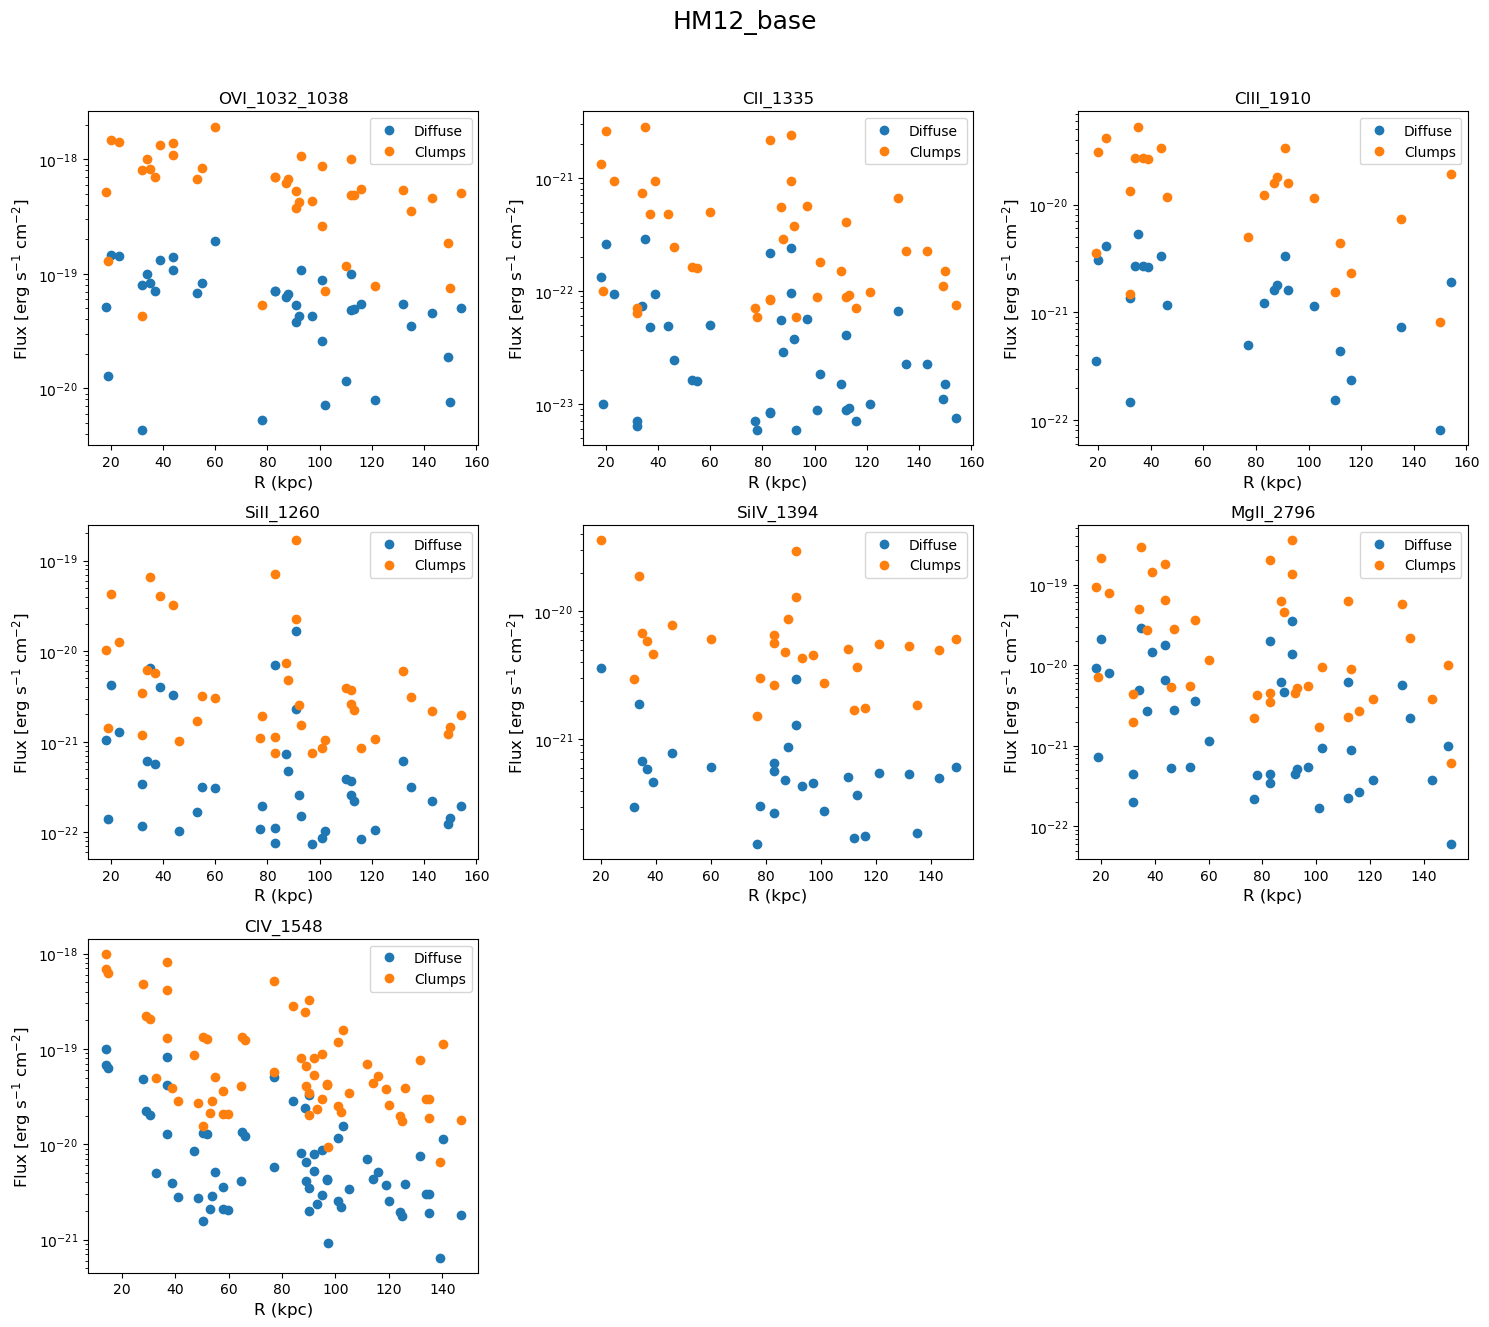

In [20]:
# ## Run the SB/Flux Calculation and Plot Results
#
# Runs both the diffuse and clumps emission models for all lines in LINE_INFO,
# using the HM12_base Cloudy grid and the COS-Halos column densities in dfN.
# Outputs a CSV and a summary figure, saveed to output directory..


def results_to_dataframe(results):
    """
    Flatten the dict of per-line DataFrames returned by run_all_lines_flux
    into a single tidy DataFrame.

    Adds a 'N_cm2' column with the linear column density [cm^-2].
    """
    frames = []
    for line_name, df in results.items():
        keep = ["obj", "ion", "z", "R_kpc", "logN", "logN_val", "F_diff", "F_cl"]
        cols = [c for c in keep if c in df.columns]
        tmp = df[cols].copy()
        tmp["line_name"] = line_name
        frames.append(tmp)

    out_df = pd.concat(frames, ignore_index=True)
    out_df["N_cm2"] = 10 ** out_df["logN_val"].astype(float)  # linear N [cm^-2]
    return out_df


# --- Run for HM12_base ---
folder_name = "HM12_base"
grid_info   = GRID_INFO[folder_name]

results = run_all_lines_flux(
    dfN=dfN,
    cloudy_path= CLOUDY_PATH,
    make_Cloudy_table=lambda idx, path: make_Cloudy_table(
        idx, path,
        grid_info["hden_n_bins"],
        grid_info["hden_min"],
        grid_info["hden_max"],
    ),
    line_info=LINE_INFO,
    line_phys=LINE_PHYS,
    aperture_arcsec2=1.0,
    delta_log_nH_clump=1.0,  # clump density = 10x the diffuse nH_diff
    r_c_kpc=1.0,
)

df_results = results_to_dataframe(results)

# Save results to CSV 
df_results.to_csv(f"/Users/vidasaeedzadeh/Documents/02-Projects/02-FOGGIE/MAGPIE/analysis/{folder_name}_cgm_emission_flux_results.csv", index=False)

# --- Summary figure: flux vs. impact parameter for each line ---
lines   = df_results["line_name"].unique()
n_lines = len(lines)
ncols   = 3
nrows   = math.ceil(n_lines / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), squeeze=False)
axes = axes.flatten()

for i, line in enumerate(lines):
    ax     = axes[i]
    subset = df_results[df_results["line_name"] == line]

    ax.plot(subset["R_kpc"], subset["F_diff"], "o", label="Diffuse")
    ax.plot(subset["R_kpc"], subset["F_cl"],   "o", label="Clumps")

    ax.set_xlabel("R (kpc)", fontsize=12)
    ax.set_ylabel("Flux [erg s$^{-1}$ cm$^{-2}$]", fontsize=12)
    ax.set_yscale("log")
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.set_title(line, fontsize=12)
    ax.legend(fontsize=10)

# hide unused subplot panels
for j in range(n_lines, len(axes)):
    axes[j].axis("off")

fig.suptitle(folder_name, fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f"/Users/vidasaeedzadeh/Documents/02-Projects/02-FOGGIE/MAGPIE/analysis/{folder_name}_flux_vs_R_subplots.png"
            , dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [21]:
# ## OVI Mass Profile from Surface Brightness
#
# Converts a radial OVI surface brightness profile into an OVI mass profile
# by inferring the emission measure in each annulus from the Cloudy emissivity,
# then converting gas mass to OVI mass via metallicity and ion fraction.

# Physical constants
mp      = 1.6726219e-24   # proton mass [g]
Msun    = 1.98847e33      # solar mass [g]
mu      = 1.3             # mean molecular weight (ionized + He)
OH_solar = 4.9e-4         # oxygen solar abundance by number (O/H)


def annulus_geometry(r_kpc):
    """
    Compute annulus bin edges and areas from bin centers.

    Edges are placed halfway between centers; the innermost/outermost
    edges are extrapolated assuming uniform spacing.

    Parameters
    ----------
    r_kpc : array   Bin centers [kpc]

    Returns
    -------
    edges_kpc         : array  length N+1
    annulus_area_kpc2 : array  length N
    """
    r_kpc = np.asarray(r_kpc, dtype=float)
    edges = np.zeros(len(r_kpc) + 1)
    edges[1:-1] = 0.5 * (r_kpc[:-1] + r_kpc[1:])
    edges[0]    = max(0.0, r_kpc[0]  - 0.5 * (r_kpc[1]  - r_kpc[0]))
    edges[-1]   =          r_kpc[-1] + 0.5 * (r_kpc[-1] - r_kpc[-2])
    annulus_area_kpc2 = np.pi * (edges[1:]**2 - edges[:-1]**2)
    return edges, annulus_area_kpc2


def ovi_mass_profile_from_sb(r_kpc, sb_obs, z, eps_ovi, nH,
                              Z_solar=0.3, f_OVI=0.2,
                              OH_solar=OH_solar, mu=mu):
    """
    Compute per-annulus and cumulative OVI mass from an observed SB profile.

    Conversion chain:
      SB_obs [erg/s/cm²/arcsec²]
        × annulus area [arcsec²]          → observed flux F_ann
        × 4π D_L²                         → intrinsic luminosity L_ann
        / (eps_ovi × nH)                  → gas volume (× mu mp)  → M_gas
        × Z × (O/H)_sun × 16 × f_OVI     → M_OVI

    Uses Planck18 cosmology (astropy) for kpc/arcsec and luminosity distance.

    Parameters
    ----------
    r_kpc   : array   Radius bin centers [kpc]
    sb_obs  : array   Observed SB [erg s^-1 cm^-2 arcsec^-2]
    z       : float   Absorber/galaxy redshift
    eps_ovi : float   OVI emissivity from Cloudy [erg s^-1 cm^3]
                      (sum of 1032+1038 components)
    nH      : float   Hydrogen density [cm^-3]
    Z_solar : float   Gas metallicity [solar units]
    f_OVI   : float   OVI ion fraction

    Returns
    -------
    DataFrame with columns: r_kpc, r_in/out_kpc, SB_obs, annulus areas,
                             F_ann, L_ann, M_gas_Msun, M_OVI_Msun, M_OVI_cum_Msun
    """
    r_kpc  = np.asarray(r_kpc,  dtype=float)
    sb_obs = np.asarray(sb_obs, dtype=float)

    edges_kpc, annulus_area_kpc2 = annulus_geometry(r_kpc)

    # physical scale at this redshift
    kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(z).to(u.kpc / u.arcsec).value

    # projected annulus area in angular units
    annulus_area_arcsec2 = annulus_area_kpc2 / kpc_per_arcsec**2

    # observed flux and intrinsic luminosity per annulus
    F_ann  = sb_obs * annulus_area_arcsec2                          # erg/s/cm²
    D_L_cm = cosmo.luminosity_distance(z).to(u.cm).value
    L_ann  = 4.0 * np.pi * D_L_cm**2 * F_ann                       # erg/s

    # gas mass from emission measure: L = eps * nH² * V → V = L/(eps*nH²)
    # M_gas = mu * mp * nH * V = mu * mp * L / (eps * nH)
    M_gas_g = mu * mp * L_ann / (eps_ovi * nH)

    # OVI mass: M_OVI = M_gas × Z × (O/H)_sun × 16 (amu) × f_OVI
    M_OVI_g = M_gas_g * Z_solar * OH_solar * 16.0 * f_OVI

    return pd.DataFrame({
        "r_kpc":               r_kpc,
        "r_in_kpc":            edges_kpc[:-1],
        "r_out_kpc":           edges_kpc[1:],
        "SB_obs":              sb_obs,
        "annulus_area_kpc2":   annulus_area_kpc2,
        "annulus_area_arcsec2":annulus_area_arcsec2,
        "F_ann":               F_ann,
        "L_ann":               L_ann,
        "M_gas_Msun":          M_gas_g  / Msun,
        "M_OVI_Msun":          M_OVI_g  / Msun,
        "M_OVI_cum_Msun":      np.cumsum(M_OVI_g) / Msun,
    })

In [22]:
# ## Input: Digitized Makani OVI Surface Brightness Profile


data = np.array([
    [0.006592812178545349, 0.8833107191316147],
    [0.16317324099243172,  0.7096336499321574],
    [0.19114597024041954,  0.689280868385346 ],
    [0.2168486692061428,   0.6417910447761194],
    [0.25154336228862817,  0.6241519674355496],
    [0.2772247892169003,   0.5576662143826323],
    [0.3029852265699903,   0.5617367706919946],
    [0.3611946376232448,   0.5427408412483039],
    [0.39027047395618863,  0.5074626865671642],
    [0.43168713087317145,  0.4925373134328358],
    [0.4529424545804014,   0.47354138398914525],
    [0.4820973013381631,   0.508819538670285 ],
    [0.5122929584997743,   0.47354138398914525],
    [0.5436266696650109,   0.4545454545454545],
    [0.5727480889353496,   0.4599728629579376],
    [0.6018421584432513,   0.44097693351424694],
    [0.6287421692312133,   0.4626865671641791],
    [0.6577967335267062,   0.40841248303934874],
    [0.7193747236534419,   0.3975576662143826],
    [0.7450363979755097,   0.31343283582089543],
    [0.7739663689087899,   0.14789687924016282],
    [0.8045023786696162,   0.41655359565807326],
    [0.8313537676576901,   0.3948439620081411],
    [0.8615220750568646,   0.3351424694708277],
    [0.863720692070544,    0.29850746268656725],
])

r_kpc  = data[:, 0] * 60                    # kpc
sb_ovi = 10**(-18 + 3 * data[:, 1])         # erg/s/cm²/arcsec²
z      = 0.459                              # Makani redshift (Rupke et al. 2019)

# --- OVI emissivity from Cloudy (HM12_base, OVI 1032+1038) ---
grid_info = GRID_INFO["HM12_base"]

make_table_HM12 = lambda idx, path: make_Cloudy_table(
    idx, path,
    grid_info["hden_n_bins"],
    grid_info["hden_min"],
    grid_info["hden_max"],
)

eps_lin_list = get_eps_linear_for_line(
    line_name="OVI_1032_1038",
    lognH0=LINE_PHYS["OVI_1032_1038"]["lognH0"],
    logT0=LINE_PHYS["OVI_1032_1038"]["logT0"],
    cloudy_path=CLOUDY_PATH,
    make_Cloudy_table=make_table_HM12,
    line_info=LINE_INFO,
)

eps_ovi = np.sum(eps_lin_list)   # sum 1032 + 1038 components
print(f"eps_OVI (1032+1038) = {eps_ovi:.3e} erg s^-1 cm^3  [log = {np.log10(eps_ovi):.2f}]")

eps_OVI (1032+1038) = 7.403e-23 erg s^-1 cm^3  [log = -22.13]


In [23]:
# ## Match OVI Fluxes to COS-Halos Galaxy Properties
#
# Adds stellar mass, sSFR, and SFR from Tumlinson et al. (2011) / Werk et al. (2012)
# to the OVI flux table produced in cell 4.
# Some QSOs have multiple absorbers; for those we match on closest redshift.

df = pd.read_csv("/Users/vidasaeedzadeh/Documents/02-Projects/02-FOGGIE/MAGPIE/analysis/HM12_base_cgm_emission_flux_results.csv")
df_ovi = df[df["ion"].str.upper() == "OVI"].copy()

#From COS-Halos table Tumlinson et al. (2011), Werk et al. (2012) I extracted:  QSO, zgal, logMstar, sSFR, N_OVI
coshalos_data = [
    # Passive
    ["J0226+0015", 0.22751, 10.94, 4.32e-13, 13.53],
    ["J0910+1014", 0.26479, 10.77, 2.39e-12, 14.21],
    ["J0928+6025", 0.15404, 10.89, 3.41e-13, 14.19],
    ["J0935+0204", 0.26228, 11.14, 6.99e-13, 13.96],
    ["J0950+4831", 0.21193, 11.34, 2.65e-13, 14.28],
    ["J1157-0022", 0.16381, 11.02, 8.46e-13, 13.56],
    ["J1617+0638", 0.15258, 11.67, 1.77e-13, 14.17],
    ["J2257+1340", 0.17676, 11.01, 1.60e-13, 14.14],
    ["J1220+3853", 0.27368, 10.86, 8.47e-13, 14.37],
    ["J1550+4001", 0.31250, 11.46, 2.09e-13, 13.73],
    ["J0943+0531", 0.14313, 11.10, 1.74e-13, 13.80],
    ["J1342-0053", 0.20127, 10.91, 1.02e-12, 13.38],

    # Star-forming
    ["J1330+2813", 0.19239, 10.47, 6.75e-11, 14.38],
    ["J0042-1037", 0.09502,  9.63, 4.31e-11, 14.78],
    ["J0401-0540", 0.21966, 10.39, 4.66e-11, 14.57],
    ["J0820+2334", 0.09505,  9.88, 8.56e-12, 14.43],
    ["J0914+2823", 0.24431, 10.27, 1.52e-10, 14.69],
    ["J0925+4004", 0.24686, 10.69, 1.77e-11, 13.94],
    ["J0943+0531", 0.22839, 10.96, 4.96e-11, 13.56],
    ["J1009+0713", 0.22788, 10.19, 2.96e-10, 15.00],
    ["J1016+4706", 0.25198, 10.29, 3.28e-11, 14.86],
    ["J1112+3539", 0.24671, 10.52, 1.72e-10, 14.70],
    ["J1233+4758", 0.22211, 10.93, 5.15e-11, 14.38],
    ["J1233-0031", 0.31850, 10.63, 8.02e-11, 14.68],
    ["J1241+5721", 0.20532, 10.24, 2.49e-10, 14.81],
    ["J1245+3356", 0.19256, 10.07, 8.92e-11, 14.34],
    ["J1342-0053", 0.22702, 10.99, 6.18e-11, 14.48],
    ["J1419+4207", 0.17928, 10.73, 2.12e-10, 14.59],
    ["J1435+3604", 0.20240, 11.18, 1.25e-10, 14.73],
    ["J1437+5045", 0.24600, 10.37, 1.83e-10, 14.57],
    ["J1445+3428", 0.21763, 10.52, 7.85e-11, 14.29],
    ["J1555+3628", 0.18930, 10.59, 1.07e-10, 14.56],
    ["J1619+3342", 0.14149, 10.21, 8.20e-11, 14.27],
    ["J0910+1014", 0.14279, 10.67, 3.02e-10, 14.70],
    ["J0943+0531", 0.35294, 10.26, 2.59e-11, 14.44],
    ["J1009+0713", 0.35569, 10.24, 1.75e-10, 15.07],
    ["J1016+4706", 0.16616, 10.62, 3.30e-11, 14.70],
    ["J1133+0327", 0.15453, 10.13, 1.36e-10, 14.43],
    ["J1241+5721", 0.21784, 10.17, 7.17e-11, 14.76],
    ["J1435+3604", 0.26227, 10.49, 1.80e-10, 14.57],
    ["J1437+5045", 0.14303, 10.07, 2.10e-10, 14.51],
    ["J1550+4001", 0.32182, 10.93, 8.71e-11, 13.68],
]


df_coshalos = pd.DataFrame(coshalos_data,
    columns=["QSO", "zgal", "logMstar", "sSFR", "N_OVI_coshalos"])
df_coshalos["Mstar"] = 10**df_coshalos["logMstar"]
df_coshalos["SFR"]   = df_coshalos["sSFR"] * df_coshalos["Mstar"]

df_ovi["obj_clean"]      = df_ovi["obj"].astype(str).str.strip()
df_coshalos["QSO_clean"] = df_coshalos["QSO"].astype(str).str.strip()
qso_counts = df_coshalos["QSO_clean"].value_counts()


def match_coshalos_row(row, cos_df, qso_counts):
    """
    Match one OVI row to its COS-Halos galaxy entry.
    For QSOs with a single galaxy: match on name alone.
    For QSOs with multiple galaxies: pick the closest redshift.
    """
    matches = cos_df[cos_df["QSO_clean"] == row["obj_clean"]]
    if len(matches) == 0:
        return pd.Series([np.nan]*6,
            index=["zgal_match","logMstar","Mstar","sSFR","SFR","N_OVI_coshalos"])

    if qso_counts.get(row["obj_clean"], 0) == 1:
        best = matches.iloc[0]
    else:
        matches = matches.copy()
        matches["dz"] = np.abs(matches["zgal"] - row["z"])
        best = matches.loc[matches["dz"].idxmin()]

    return pd.Series(
        [best["zgal"], best["logMstar"], best["Mstar"],
         best["sSFR"], best["SFR"], best["N_OVI_coshalos"]],
        index=["zgal_match","logMstar","Mstar","sSFR","SFR","N_OVI_coshalos"]
    )


df_ovi[["zgal_match","logMstar","Mstar","sSFR","SFR","N_OVI_coshalos"]] = df_ovi.apply(
    match_coshalos_row, axis=1, cos_df=df_coshalos, qso_counts=qso_counts)

unmatched = df_ovi[df_ovi["sSFR"].isna()][["obj","z"]].drop_duplicates()
print(f"Unmatched OVI rows: {len(unmatched)}")

# Save final subset used for figures
df_sub = df_ovi[["obj","ion","F_diff","F_cl","sSFR","SFR","N_OVI_coshalos"]].dropna(subset=["sSFR"])
df_sub.to_csv("/Users/vidasaeedzadeh/Documents/02-Projects/02-FOGGIE/MAGPIE/analysis/subset_OVI_with_sSFR_SFR.csv", index=False)
print("Saved: subset_OVI_with_sSFR_SFR.csv")

Unmatched OVI rows: 1
Saved: subset_OVI_with_sSFR_SFR.csv
